In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('../data/preprocessed/city_day_cleaned_v1.csv')

In [21]:
df.head(20)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Month,Temperature,Humidity,Wind_Speed
0,Ahmedabad,2015-01-29,83.13,107.67,6.93,28.71,33.72,17.055,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor,1,18.5,53.6,4.2
1,Ahmedabad,2015-01-30,79.84,107.67,13.85,28.68,41.08,17.055,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor,1,22.1,52.9,4.9
2,Ahmedabad,2015-01-31,94.52,107.67,24.39,32.66,52.61,17.055,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe,1,18.3,52.6,7.6
3,Ahmedabad,2015-02-01,135.99,107.67,43.48,42.08,84.57,17.055,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe,2,19.9,58.0,8.5
4,Ahmedabad,2015-02-02,178.33,107.67,54.56,35.31,72.80,17.055,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe,2,18.5,46.5,6.7
5,Ahmedabad,2015-02-03,139.70,107.67,30.61,28.40,56.73,17.055,30.61,33.79,73.60,0.17,0.03,11.87,660.0,Severe,2,16.0,58.7,7.8
6,Ahmedabad,2015-02-04,80.65,107.67,2.37,22.83,24.00,17.055,2.37,25.73,47.30,0.00,0.00,0.00,294.0,Poor,2,20.8,52.2,3.3
7,Ahmedabad,2015-02-05,58.36,107.67,2.60,21.39,23.31,17.055,2.60,32.66,53.54,0.00,0.00,0.00,149.0,Moderate,2,21.2,60.9,4.5
8,Ahmedabad,2015-02-06,79.29,107.67,1.16,26.94,26.83,17.055,1.16,67.41,59.30,0.00,0.00,0.00,190.0,Moderate,2,16.0,59.9,3.2
9,Ahmedabad,2015-02-07,88.70,107.67,7.29,31.32,37.73,17.055,7.29,80.09,44.76,0.00,0.00,0.00,247.0,Poor,2,19.4,54.2,8.9


In [22]:
df.shape

(24850, 20)

In [23]:
df.isna().sum()

City           0
Date           0
PM2.5          0
PM10           0
NO             0
NO2            0
NOx            0
NH3            0
CO             0
SO2            0
O3             0
Benzene        0
Toluene        0
Xylene         0
AQI            0
AQI_Bucket     0
Month          0
Temperature    0
Humidity       0
Wind_Speed     0
dtype: int64

In [24]:
# Drop columns with missing values and unwanted columns
df_final = df.dropna(axis=1)
df_final = df_final.drop(columns=['Date', 'Benzene', 'Toluene', 'Xylene'])

# Check results
print("Original shape:", df.shape)
print("Final shape:", df_final.shape)
print("Final columns:", df_final.columns.tolist())
print("Missing values:", df_final.isnull().sum().sum())


Original shape: (24850, 20)
Final shape: (24850, 16)
Final columns: ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI', 'AQI_Bucket', 'Month', 'Temperature', 'Humidity', 'Wind_Speed']
Missing values: 0


In [25]:
df.duplicated().sum()

np.int64(0)

In [27]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 24850 entries, 0 to 24849
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         24850 non-null  str    
 1   PM2.5        24850 non-null  float64
 2   PM10         24850 non-null  float64
 3   NO           24850 non-null  float64
 4   NO2          24850 non-null  float64
 5   NOx          24850 non-null  float64
 6   NH3          24850 non-null  float64
 7   CO           24850 non-null  float64
 8   SO2          24850 non-null  float64
 9   O3           24850 non-null  float64
 10  AQI          24850 non-null  float64
 11  AQI_Bucket   24850 non-null  str    
 12  Month        24850 non-null  int64  
 13  Temperature  24850 non-null  float64
 14  Humidity     24850 non-null  float64
 15  Wind_Speed   24850 non-null  float64
dtypes: float64(13), int64(1), str(2)
memory usage: 3.0 MB


In [28]:
df.nunique()

City              26
Date            2009
PM2.5          11552
PM10           12273
NO              5657
NO2             7314
NOx             7796
NH3             5843
CO              1677
SO2             4615
O3              7587
Benzene         1828
Toluene         3574
Xylene          1547
AQI              829
AQI_Bucket         6
Month             12
Temperature      376
Humidity         401
Wind_Speed       176
dtype: int64

In [29]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Month,Temperature,Humidity,Wind_Speed
count,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000
mean,67.097109,113.434930,17.569894,28.761585,31.671709,23.129938,2.318160,14.406159,34.736290,3.136560,8.014925,2.509089,166.463581,6.281851,29.894519,64.421630,8.001827
std,62.285191,78.581712,22.268838,24.521451,29.644130,22.764447,7.019496,17.307963,21.460501,14.874703,18.507471,4.288183,140.696585,3.437407,7.976301,9.878131,3.473343
min,0.040000,0.030000,0.030000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000,1.000000,11.100000,45.000000,0.000000
25%,29.480000,58.322500,5.710000,11.832500,14.010000,10.740000,0.580000,5.790000,19.440000,0.290000,1.250000,1.760000,81.000000,3.000000,24.500000,56.700000,5.400000
50%,49.240000,100.140000,9.950000,21.845000,23.790000,17.055000,0.920000,9.250000,31.180000,1.220000,3.370000,1.780000,118.000000,6.000000,29.200000,62.600000,7.800000
75%,79.580000,134.217500,20.030000,37.937500,38.210000,29.557500,1.470000,15.220000,45.410000,2.960000,7.437500,1.790000,208.000000,9.000000,36.100000,72.200000,10.600000
max,914.940000,917.080000,390.680000,362.210000,378.240000,352.890000,175.810000,186.080000,257.730000,455.030000,454.850000,170.370000,2049.000000,12.000000,50.400000,85.000000,17.800000


In [30]:
df.head(20)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Month,Temperature,Humidity,Wind_Speed
0,Ahmedabad,2015-01-29,83.13,107.67,6.93,28.71,33.72,17.055,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor,1,18.5,53.6,4.2
1,Ahmedabad,2015-01-30,79.84,107.67,13.85,28.68,41.08,17.055,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor,1,22.1,52.9,4.9
2,Ahmedabad,2015-01-31,94.52,107.67,24.39,32.66,52.61,17.055,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe,1,18.3,52.6,7.6
3,Ahmedabad,2015-02-01,135.99,107.67,43.48,42.08,84.57,17.055,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe,2,19.9,58.0,8.5
4,Ahmedabad,2015-02-02,178.33,107.67,54.56,35.31,72.80,17.055,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe,2,18.5,46.5,6.7
5,Ahmedabad,2015-02-03,139.70,107.67,30.61,28.40,56.73,17.055,30.61,33.79,73.60,0.17,0.03,11.87,660.0,Severe,2,16.0,58.7,7.8
6,Ahmedabad,2015-02-04,80.65,107.67,2.37,22.83,24.00,17.055,2.37,25.73,47.30,0.00,0.00,0.00,294.0,Poor,2,20.8,52.2,3.3
7,Ahmedabad,2015-02-05,58.36,107.67,2.60,21.39,23.31,17.055,2.60,32.66,53.54,0.00,0.00,0.00,149.0,Moderate,2,21.2,60.9,4.5
8,Ahmedabad,2015-02-06,79.29,107.67,1.16,26.94,26.83,17.055,1.16,67.41,59.30,0.00,0.00,0.00,190.0,Moderate,2,16.0,59.9,3.2
9,Ahmedabad,2015-02-07,88.70,107.67,7.29,31.32,37.73,17.055,7.29,80.09,44.76,0.00,0.00,0.00,247.0,Poor,2,19.4,54.2,8.9


In [31]:
# Check unique categories for categorical variables
print("Categories in 'City' variable:", df['City'].unique())
print("Categories in 'AQI_Bucket' variable:", df['AQI_Bucket'].unique())
print("Categories in 'Month' variable:", df['Month'].unique())


Categories in 'City' variable: <StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str
Categories in 'AQI_Bucket' variable: <StringArray>
['Poor', 'Very Poor', 'Severe', 'Moderate', 'Satisfactory', 'Good']
Length: 6, dtype: str
Categories in 'Month' variable: [ 1  2  3  4  5  6  7  8  9 10 11 12]


In [32]:
# Define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# Print results
print('\nWe have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))



We have 20 numerical features : ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Month', 'Temperature', 'Humidity', 'Wind_Speed']

We have 0 categorical features : []


In [33]:
df.head(2)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Month,Temperature,Humidity,Wind_Speed
0,Ahmedabad,2015-01-29,83.13,107.67,6.93,28.71,33.72,17.055,6.93,49.52,59.76,0.02,0.0,3.14,209.0,Poor,1,18.5,53.6,4.2
1,Ahmedabad,2015-01-30,79.84,107.67,13.85,28.68,41.08,17.055,13.85,48.49,97.07,0.04,0.0,4.81,328.0,Very Poor,1,22.1,52.9,4.9


In [34]:
# Create a new column for total pollution load
df['Total_Pollution'] = df['PM2.5'] + df['PM10'] + df['NO'] + df['NO2'] + df['NOx'] + df['CO'] + df['SO2'] + df['O3']

# Create a new column for average pollution level
df['Average_Pollution'] = df['Total_Pollution'] / 8   # dividing by number of pollutants included

# Preview the updated dataset
df.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Toluene,Xylene,AQI,AQI_Bucket,Month,Temperature,Humidity,Wind_Speed,Total_Pollution,Average_Pollution
0,Ahmedabad,2015-01-29,83.13,107.67,6.93,28.71,33.72,17.055,6.93,49.52,...,0.00,3.14,209.0,Poor,1,18.5,53.6,4.2,376.37,47.04625
1,Ahmedabad,2015-01-30,79.84,107.67,13.85,28.68,41.08,17.055,13.85,48.49,...,0.00,4.81,328.0,Very Poor,1,22.1,52.9,4.9,430.53,53.81625
2,Ahmedabad,2015-01-31,94.52,107.67,24.39,32.66,52.61,17.055,24.39,67.39,...,0.01,7.67,514.0,Severe,1,18.3,52.6,7.6,514.96,64.37000
3,Ahmedabad,2015-02-01,135.99,107.67,43.48,42.08,84.57,17.055,43.48,75.23,...,0.04,25.87,782.0,Severe,2,19.9,58.0,8.5,635.20,79.40000
4,Ahmedabad,2015-02-02,178.33,107.67,54.56,35.31,72.80,17.055,54.56,55.04,...,0.06,35.61,914.0,Severe,2,18.5,46.5,6.7,665.65,83.20625


In [35]:
# Count rows where pollutants reach very high values
pm25_high = df[df['PM2.5'] >= 300]['AQI'].count()
pm10_high = df[df['PM10'] >= 300]['AQI'].count()
no2_high = df[df['NO2'] >= 200]['AQI'].count()

print(f'Number of records with very high PM2.5: {pm25_high}')
print(f'Number of records with very high PM10: {pm10_high}')
print(f'Number of records with very high NO2: {no2_high}')


Number of records with very high PM2.5: 276
Number of records with very high PM10: 914
Number of records with very high NO2: 27


In [36]:
# Count rows where pollutants are very low
pm25_low = df[df['PM2.5'] <= 20]['AQI'].count()
pm10_low = df[df['PM10'] <= 20]['AQI'].count()
no2_low = df[df['NO2'] <= 20]['AQI'].count()

print(f'Number of records with very low PM2.5: {pm25_low}')
print(f'Number of records with very low PM10: {pm10_low}')
print(f'Number of records with very low NO2: {no2_low}')


Number of records with very low PM2.5: 3175
Number of records with very low PM10: 377
Number of records with very low NO2: 11376


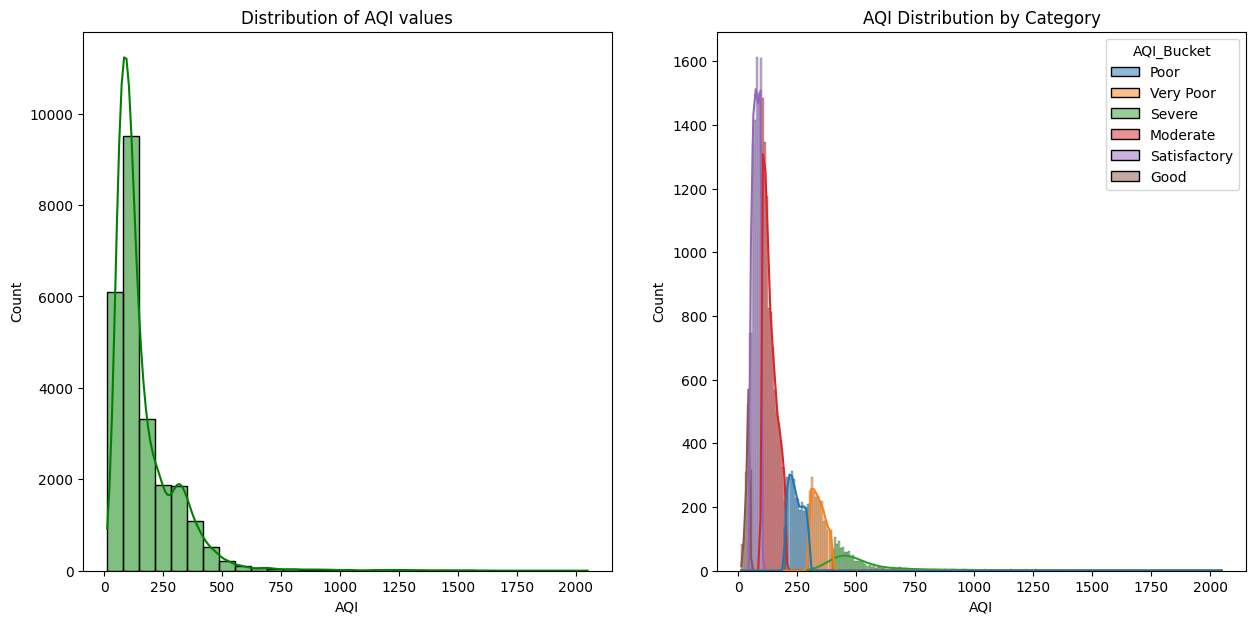

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Left plot: Histogram + KDE of AQI
plt.subplot(121)
sns.histplot(data=df, x='AQI', bins=30, kde=True, color='g')
plt.title("Distribution of AQI values")

# Right plot: Histogram + KDE of AQI by AQI_Bucket
plt.subplot(122)
sns.histplot(data=df, x='AQI', kde=True, hue='AQI_Bucket')
plt.title("AQI Distribution by Category")

plt.show()


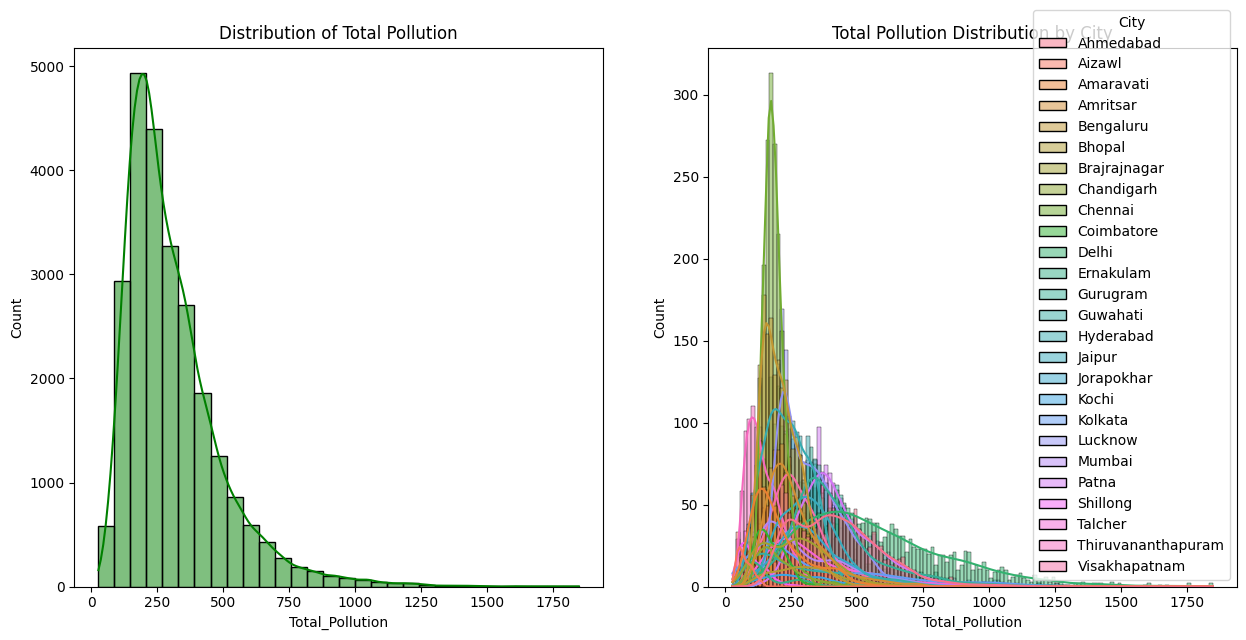

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Left plot: Histogram + KDE of Total Pollution
plt.subplot(121)
sns.histplot(data=df, x='Total_Pollution', bins=30, kde=True, color='g')
plt.title("Distribution of Total Pollution")

# Right plot: Histogram + KDE of Total Pollution by City
plt.subplot(122)
sns.histplot(data=df, x='Total_Pollution', kde=True, hue='City')
plt.title("Total Pollution Distribution by City")

plt.show()


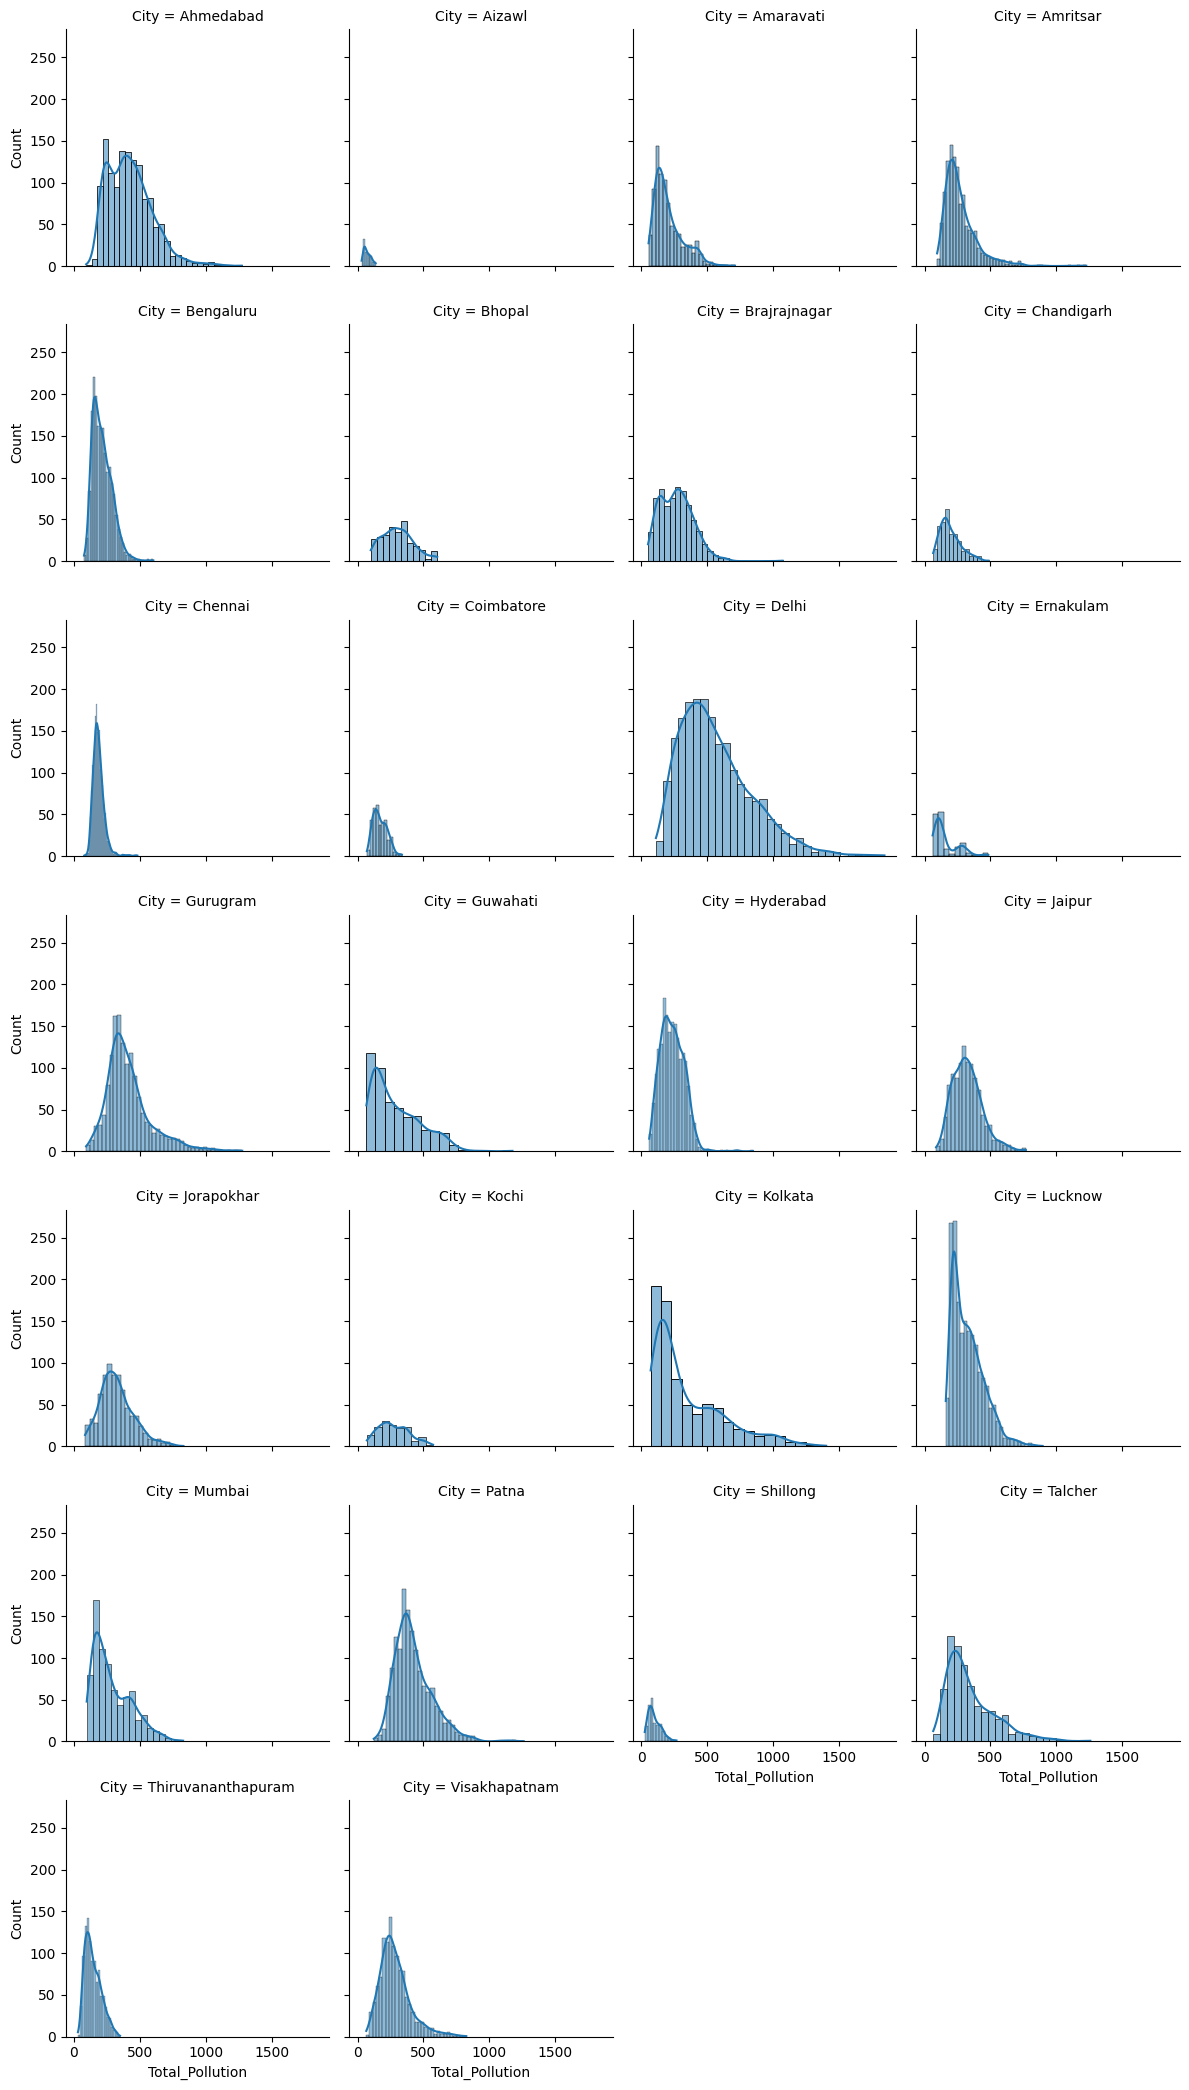

In [39]:
g = sns.FacetGrid(df, col="City", col_wrap=4, height=3)
g.map(sns.histplot, "Total_Pollution", kde=True)
plt.show()


<Axes: xlabel='City'>

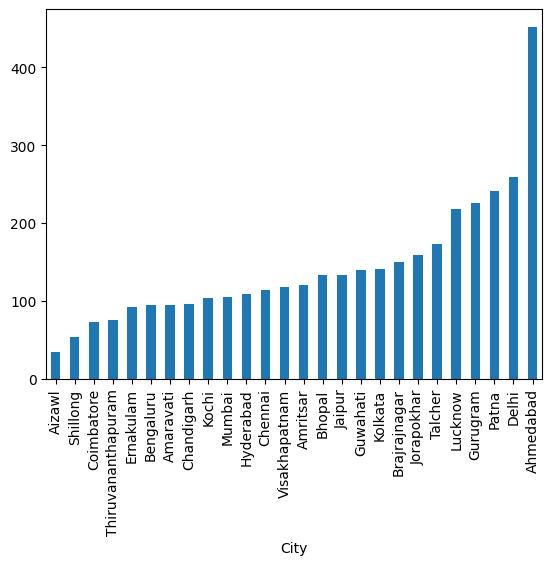

In [40]:
df.groupby('City')['AQI'].mean().sort_values().plot(kind='bar')


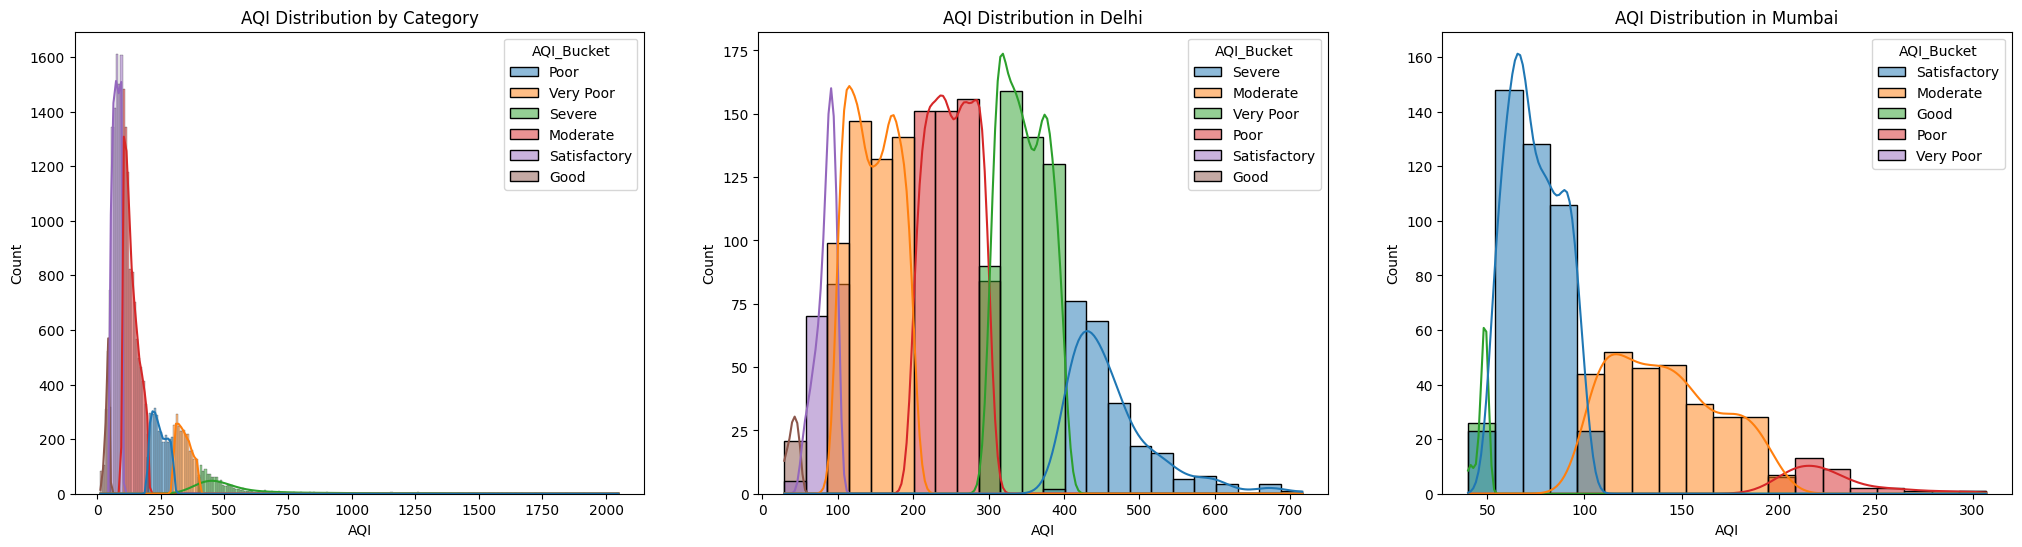

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create 3 subplots side by side
plt.subplots(1, 3, figsize=(25, 6))

# 1st plot: AQI distribution by AQI_Bucket
plt.subplot(131)
sns.histplot(data=df, x='AQI', kde=True, hue='AQI_Bucket')
plt.title("AQI Distribution by Category")

# 2nd plot: AQI distribution for one city 
plt.subplot(132)
sns.histplot(data=df[df['City']=='Delhi'], x='AQI', kde=True, hue='AQI_Bucket')
plt.title("AQI Distribution in Delhi")

# 3rd plot: AQI distribution for another city 
plt.subplot(133)
sns.histplot(data=df[df['City']=='Mumbai'], x='AQI', kde=True, hue='AQI_Bucket')
plt.title("AQI Distribution in Mumbai")

plt.show()


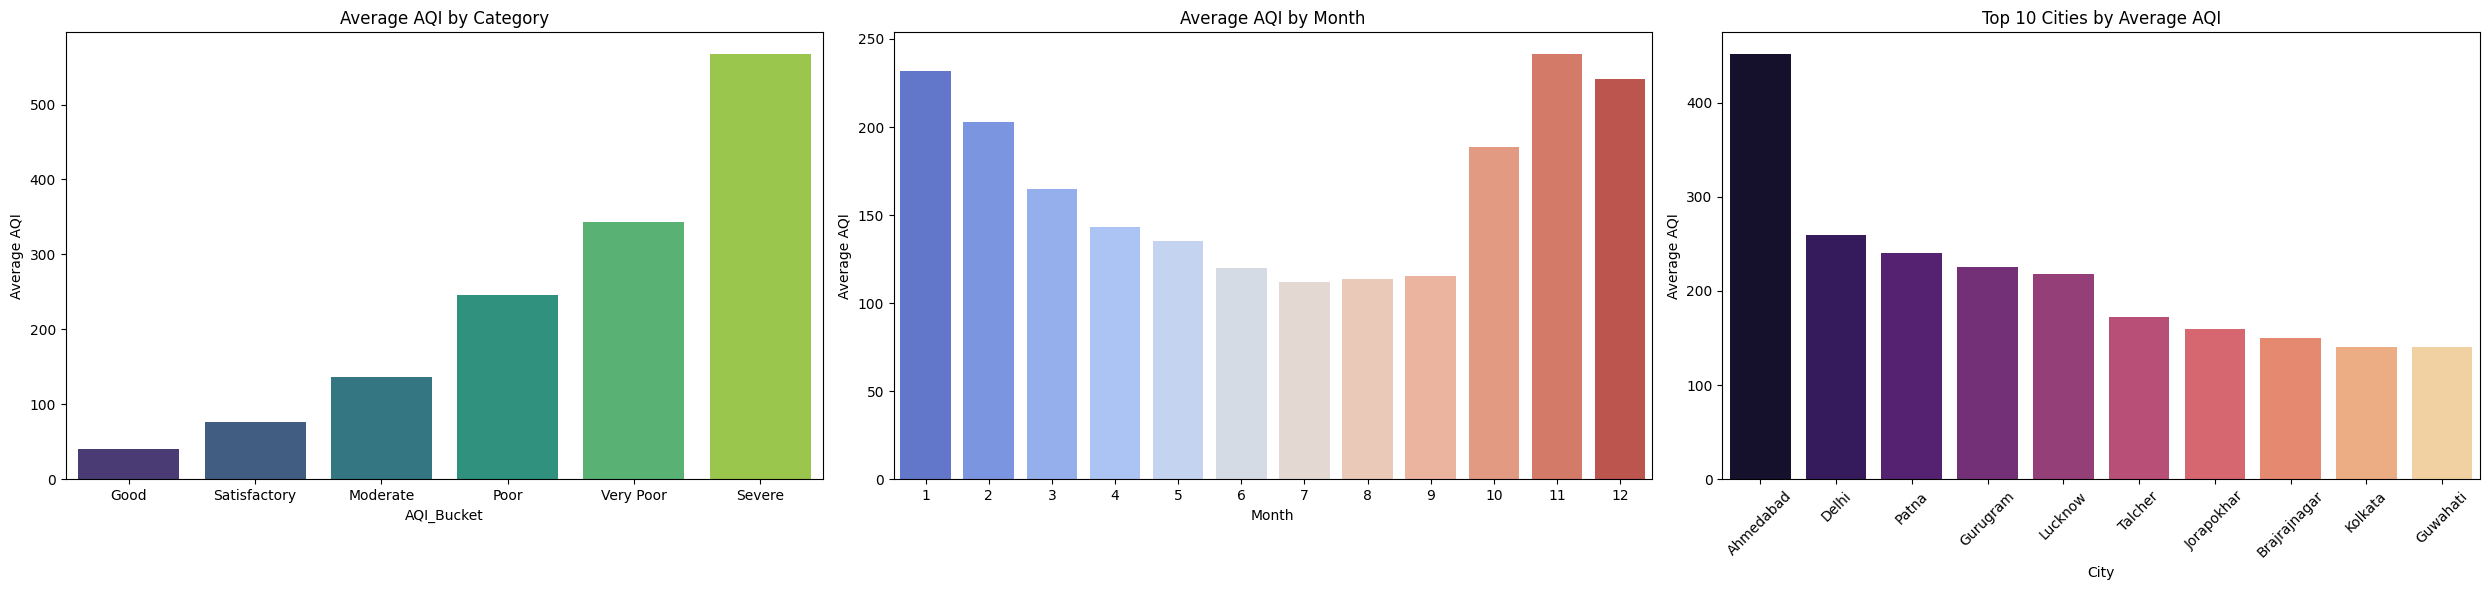

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplots(1, 3, figsize=(25, 6))

# 1st plot: Average AQI by AQI_Bucket
plt.subplot(131)
bucket_avg = df.groupby('AQI_Bucket')['AQI'].mean().sort_values()
sns.barplot(x=bucket_avg.index, y=bucket_avg.values, palette="viridis")
plt.title("Average AQI by Category")
plt.xlabel("AQI_Bucket")
plt.ylabel("Average AQI")

# 2nd plot: Average AQI by Month
plt.subplot(132)
month_avg = df.groupby('Month')['AQI'].mean()
sns.barplot(x=month_avg.index, y=month_avg.values, palette="coolwarm")
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")

# 3rd plot: Average AQI by City (Top 10 only for clarity)
plt.subplot(133)
city_avg = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=city_avg.index, y=city_avg.values, palette="magma")
plt.title("Top 10 Cities by Average AQI")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


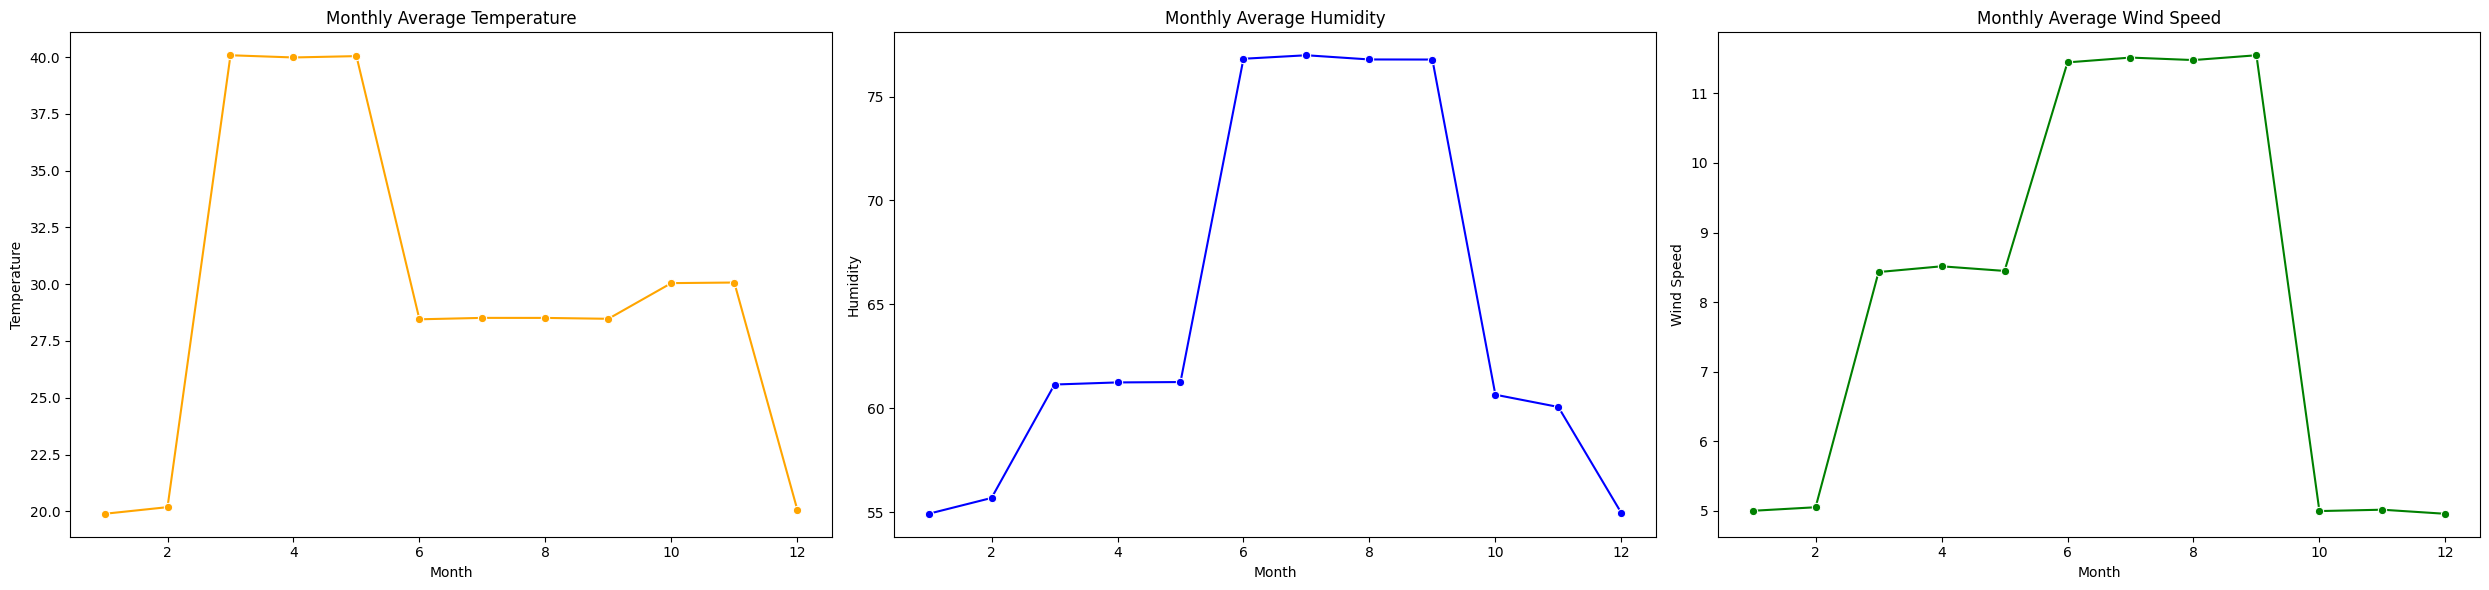

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplots(1, 3, figsize=(25, 6))

# 1st plot: Average Temperature by Month
plt.subplot(131)
temp_avg = df.groupby('Month')['Temperature'].mean()
sns.lineplot(x=temp_avg.index, y=temp_avg.values, marker='o', color='orange')
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")

# 2nd plot: Average Humidity by Month
plt.subplot(132)
humidity_avg = df.groupby('Month')['Humidity'].mean()
sns.lineplot(x=humidity_avg.index, y=humidity_avg.values, marker='o', color='blue')
plt.title("Monthly Average Humidity")
plt.xlabel("Month")
plt.ylabel("Humidity")

# 3rd plot: Average Wind Speed by Month
plt.subplot(133)
speed_avg = df.groupby('Month')['Wind_Speed'].mean()
sns.lineplot(x=speed_avg.index, y=speed_avg.values, marker='o', color='green')
plt.title("Monthly Average Wind Speed")
plt.xlabel("Month")
plt.ylabel("Wind Speed")

plt.tight_layout()
plt.show()


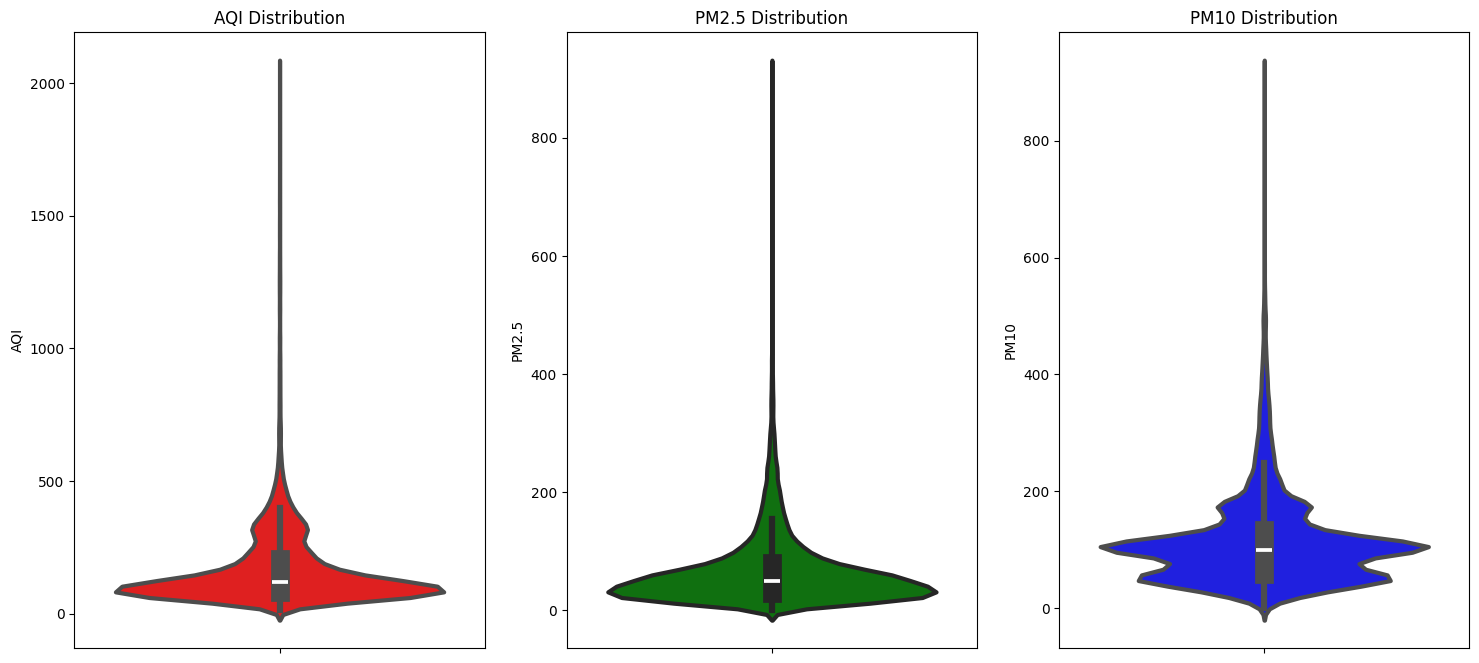

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,8))

# 1st plot: AQI distribution
plt.subplot(131)
plt.title('AQI Distribution')
sns.violinplot(y='AQI', data=df, color='red', linewidth=3)

# 2nd plot: PM2.5 distribution
plt.subplot(132)
plt.title('PM2.5 Distribution')
sns.violinplot(y='PM2.5', data=df, color='green', linewidth=3)

# 3rd plot: PM10 distribution
plt.subplot(133)
plt.title('PM10 Distribution')
sns.violinplot(y='PM10', data=df, color='blue', linewidth=3)

plt.show()


In [45]:
import pandas as pd

# Load the dataset
df = pd.read_csv("C:/Users/diyad/Downloads/city_day_cleaned_v1.csv")

# Quick check
print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/diyad/Downloads/city_day_cleaned_v1.csv'

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode City column
le_city = LabelEncoder()
df['City'] = le_city.fit_transform(df['City'])

# Check mapping
city_mapping = dict(zip(le_city.classes_, le_city.transform(le_city.classes_)))
print("City Encoding:", city_mapping)


In [ ]:
# Encode AQI_Bucket column
le_bucket = LabelEncoder()
df['AQI_Bucket'] = le_bucket.fit_transform(df['AQI_Bucket'])

# Check mapping
bucket_mapping = dict(zip(le_bucket.classes_, le_bucket.transform(le_bucket.classes_)))
print("AQI_Bucket Encoding:", bucket_mapping)


In [ ]:
print(df[['City','AQI_Bucket']].head())


In [ ]:
import pandas as pd

# Load your CSV file into a DataFrame
df = pd.read_csv("C:/Users/diyad/Downloads/city_day_cleaned_final.csv")

# Quick check
print(df.head())


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

# Plot boxplots for each numeric column
plt.figure(figsize=(16, 5 * ((len(numeric_cols)//4) + 1)))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(((len(numeric_cols)//4) + 1), 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()


In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the features you want to treat
features = ['PM2.5','PM10','NO2','SO2','CO','NOx','NH3','NO','O3']

def cap_outliers(df, columns):
    """
    Detects and caps outliers for given numeric columns using IQR method.
    Ensures no values lie outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR].
    """
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Clip values strictly to the limits
        df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)
    return df

# Apply to your dataset
df = cap_outliers(df, features)

# Quick check: show summary after treatment
print(df[features].describe())

# Visualize boxplots after treatment
plt.figure(figsize=(12,6))
sns.boxplot(data=df[features])
plt.xticks(rotation=45)
plt.title("Boxplots after Outlier Treatment")
plt.show()


In [46]:
import numpy as np
import pandas as pd

# Define pollutant features
features = ['PM2.5','PM10','NO2','SO2','CO','NOx','NH3','NO','O3']

def cap_outliers(df, columns):
    """
    Detects and caps outliers for given numeric columns using IQR method.
    Ensures no values lie outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR].
    """
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Clip values strictly to the limits
        df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)
    return df

# Apply to your dataset
df = cap_outliers(df, features)

# Quick check
print(df[features].describe())


              PM2.5          PM10           NO2           SO2            CO  \
count  24850.000000  24850.000000  24850.000000  24850.000000  24850.000000   
mean      60.882153    107.689724     27.478494     11.792764      1.120038   
std       41.653620     60.105490     19.794958      8.130664      0.772831   
min        0.040000      0.030000      0.010000      0.010000      0.000000   
25%       29.480000     58.322500     11.832500      5.790000      0.580000   
50%       49.240000    100.140000     21.845000      9.250000      0.920000   
75%       79.580000    134.217500     37.937500     15.220000      1.470000   
max      154.730000    248.060000     77.095000     29.365000      2.805000   

                NOx           NH3            NO            O3  
count  24850.000000  24850.000000  24850.000000  24850.000000  
mean      28.801505     21.343800     14.567056     34.170947  
std       20.594667     14.617211     12.221096     19.553773  
min        0.000000      0.01000

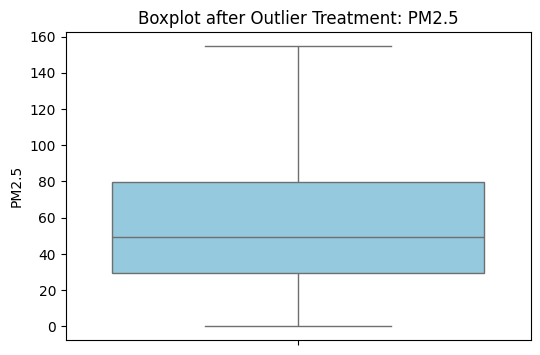

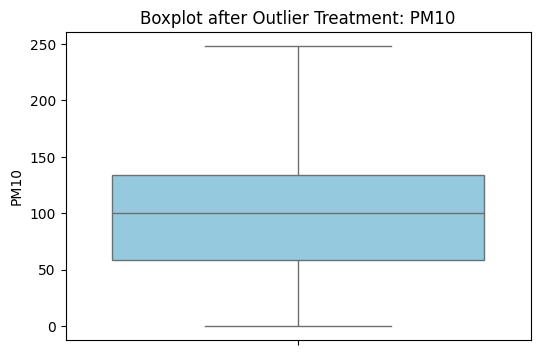

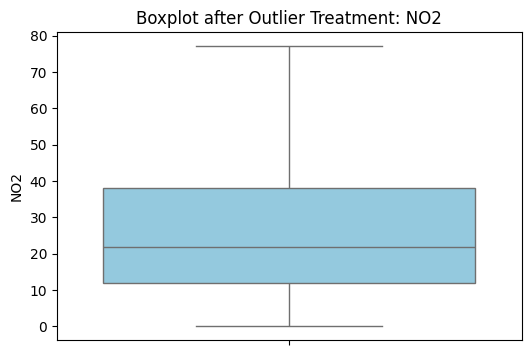

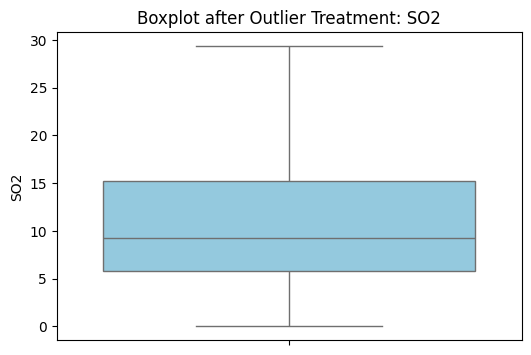

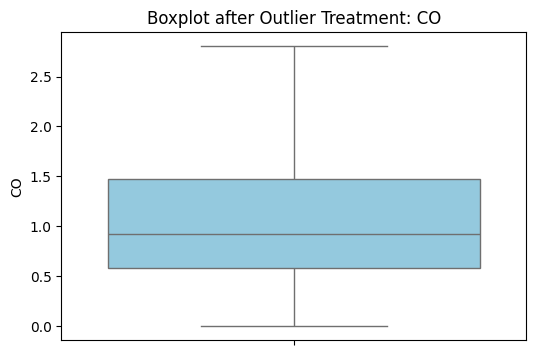

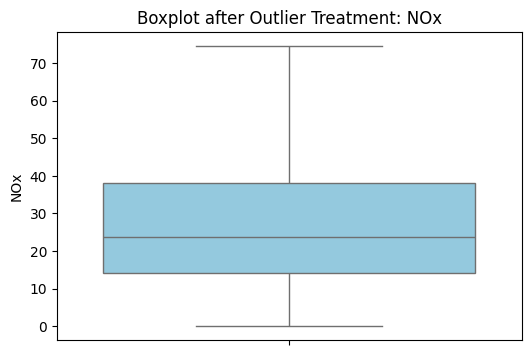

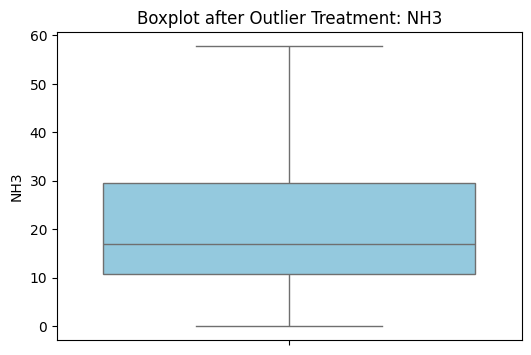

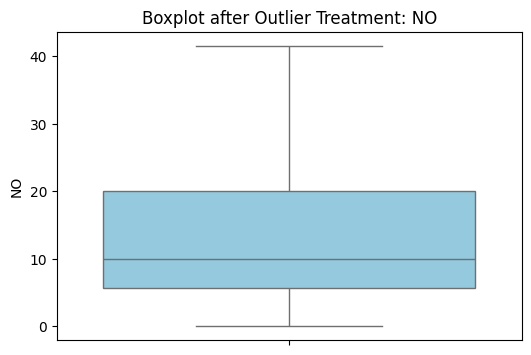

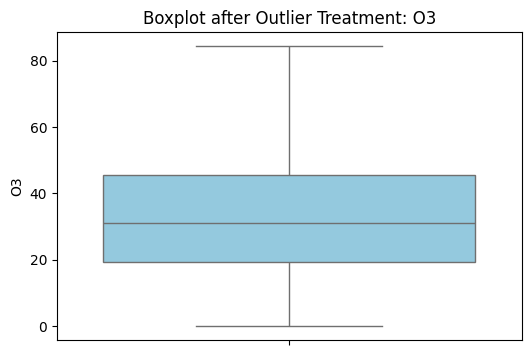

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"Boxplot after Outlier Treatment: {col}")
    plt.show()


In [48]:
Q1 = df['AQI'].quantile(0.25)
Q3 = df['AQI'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['AQI'] = df['AQI'].clip(lower=lower_limit, upper=upper_limit)


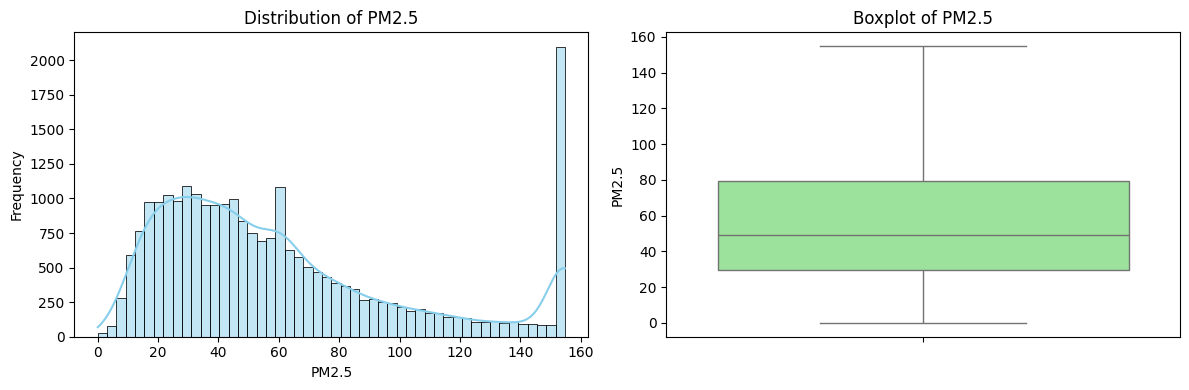

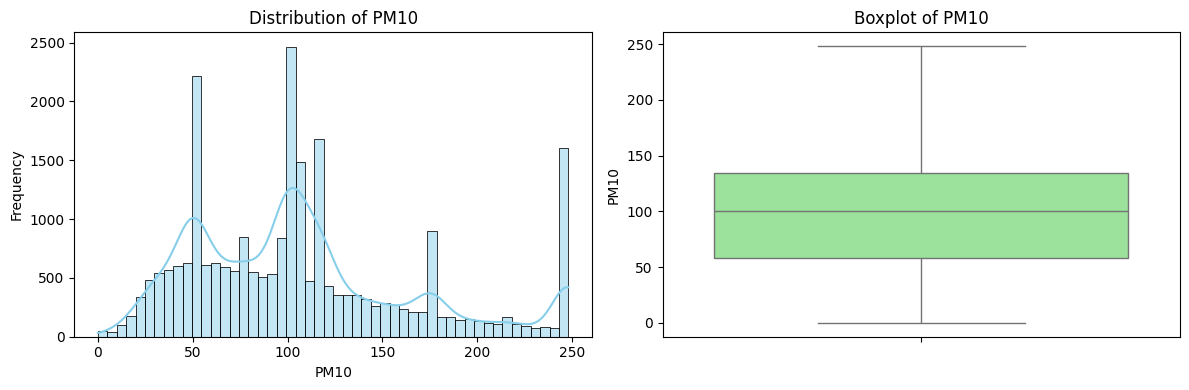

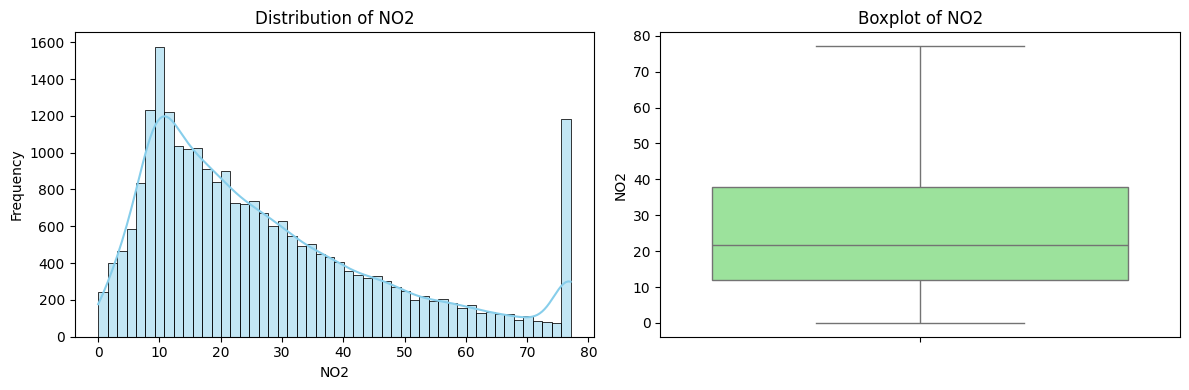

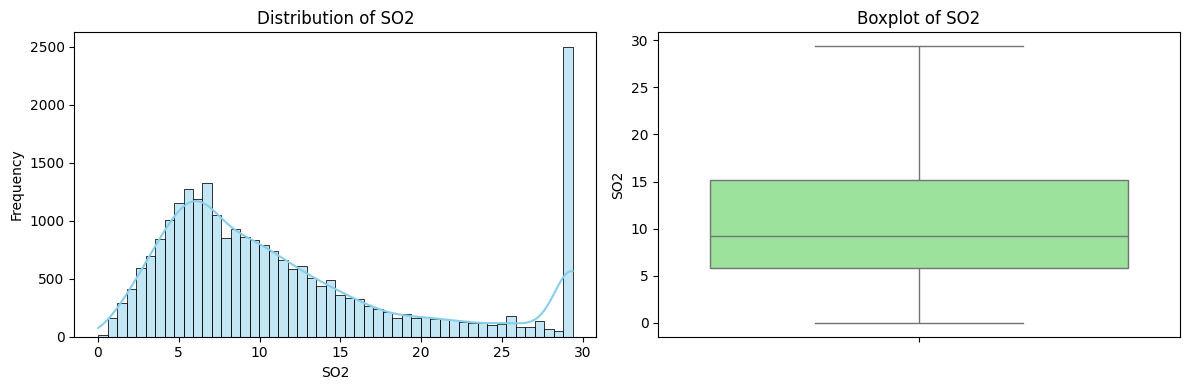

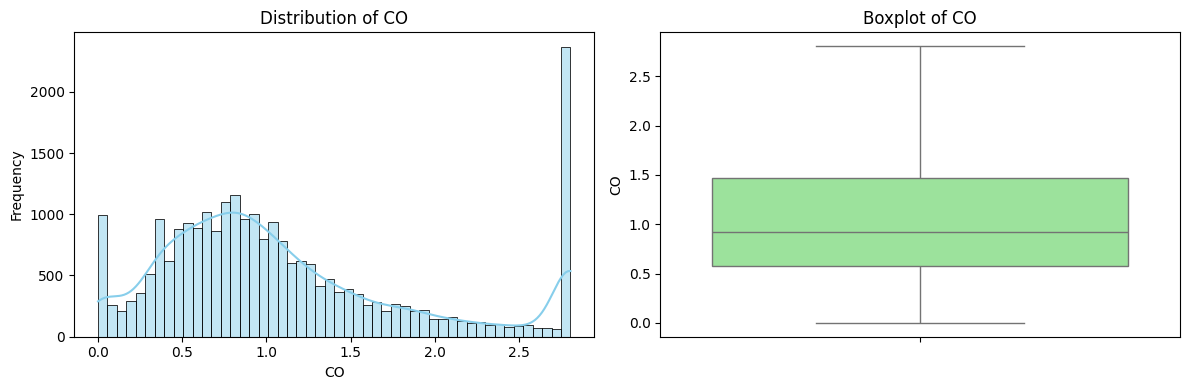

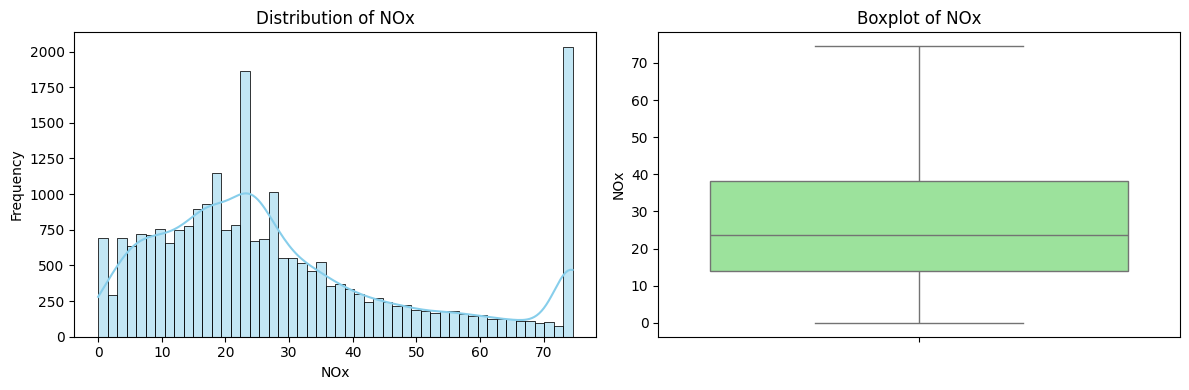

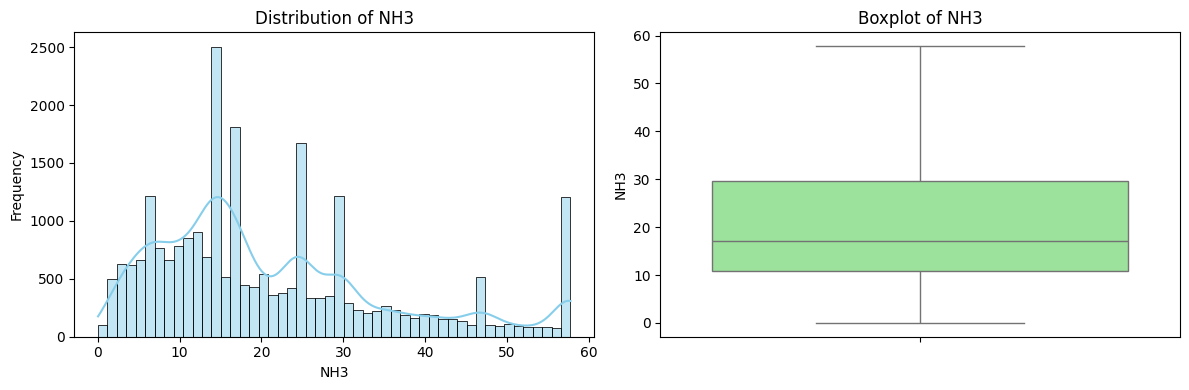

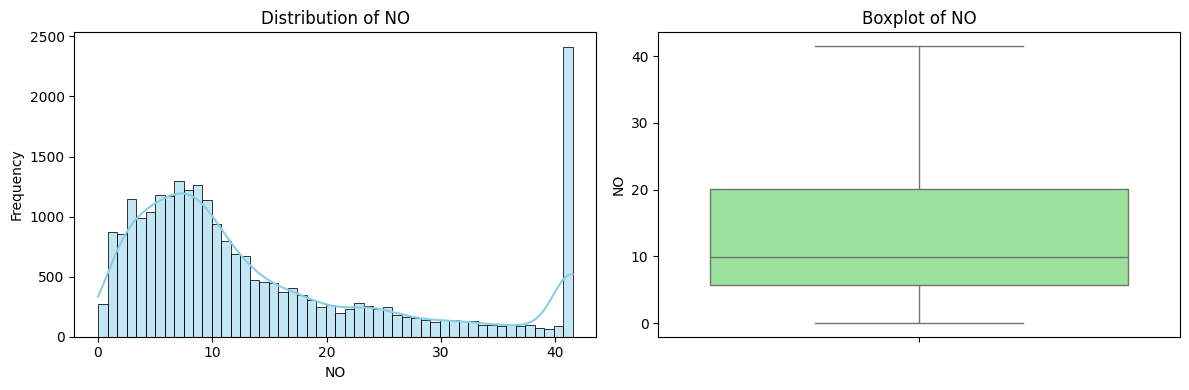

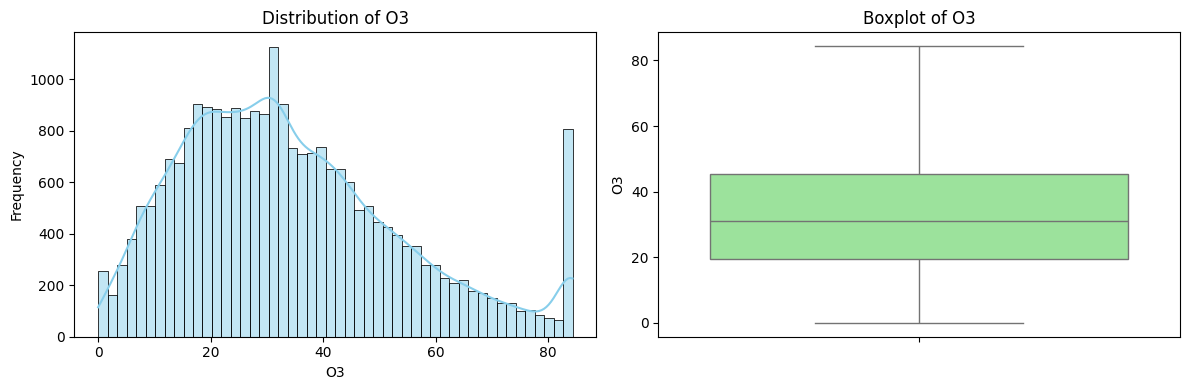

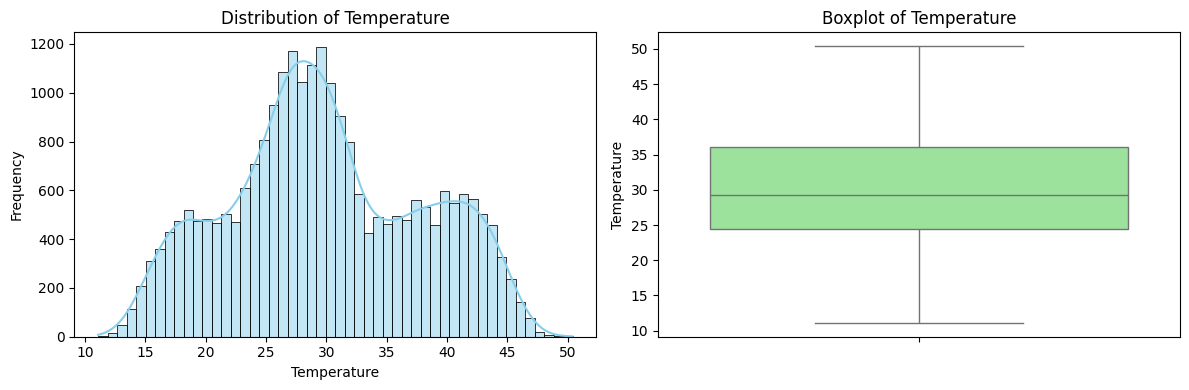

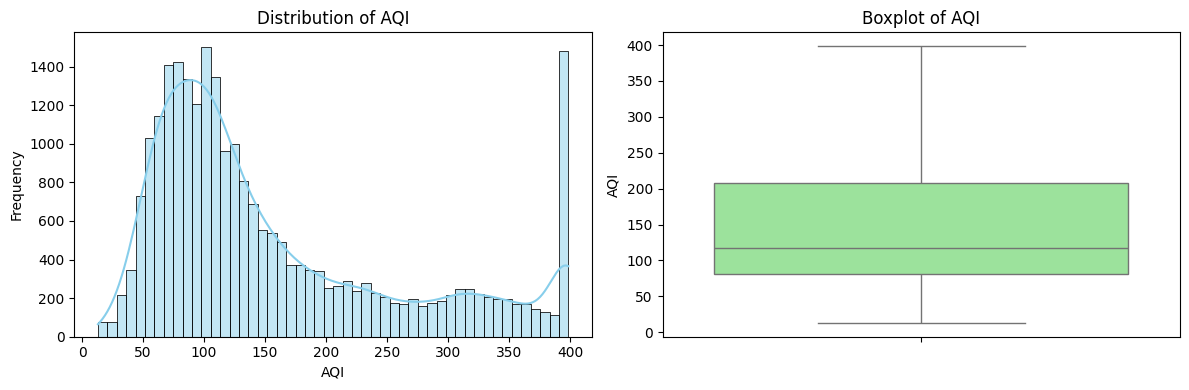

In [49]:
#UNIVARIATE ANALYSIS
import seaborn as sns
import matplotlib.pyplot as plt

# Define numeric features to analyze
features = ['PM2.5','PM10','NO2','SO2','CO','NOx','NH3','NO','O3','Temperature','AQI']

# Loop through features
for col in features:
    plt.figure(figsize=(12,4))

    # Histogram with KDE
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=50, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()


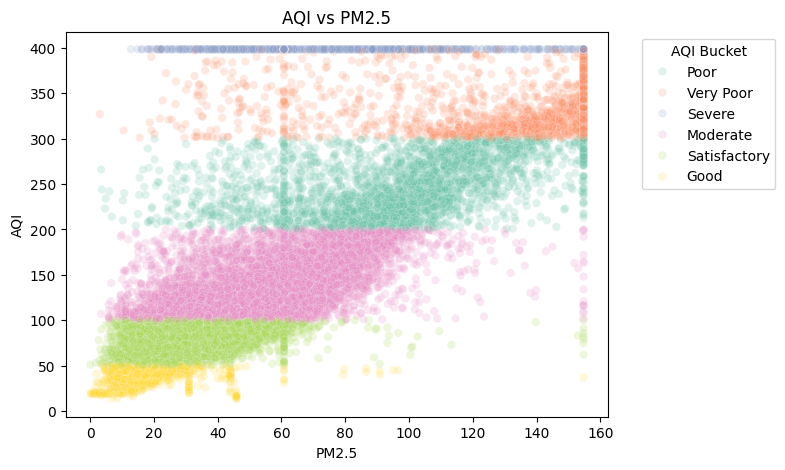

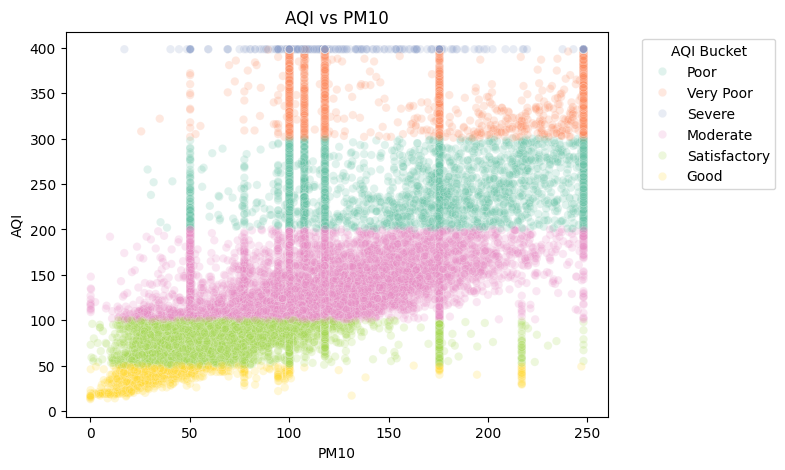

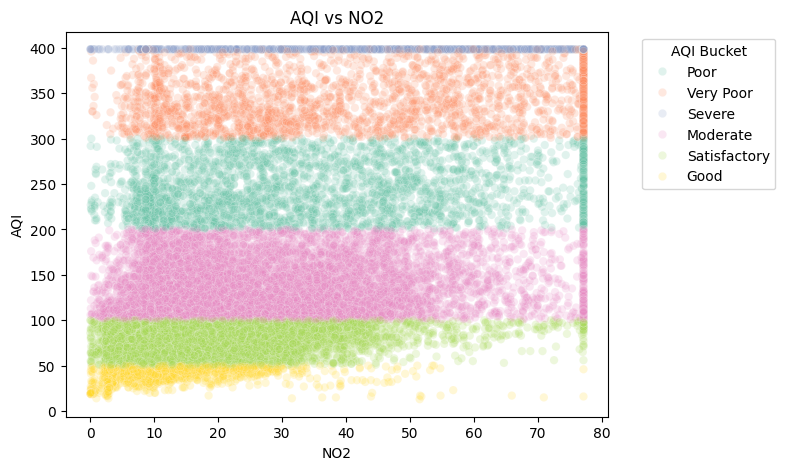

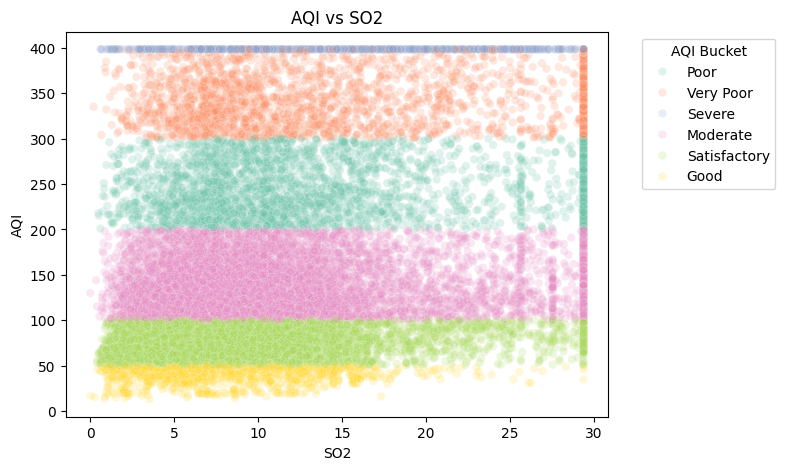

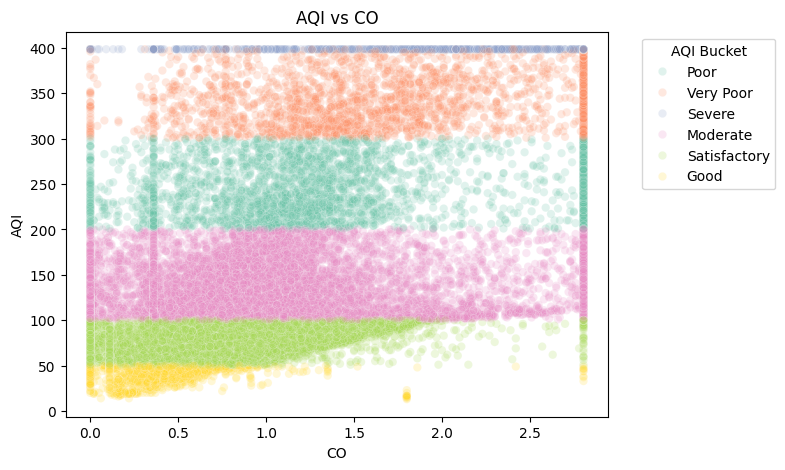

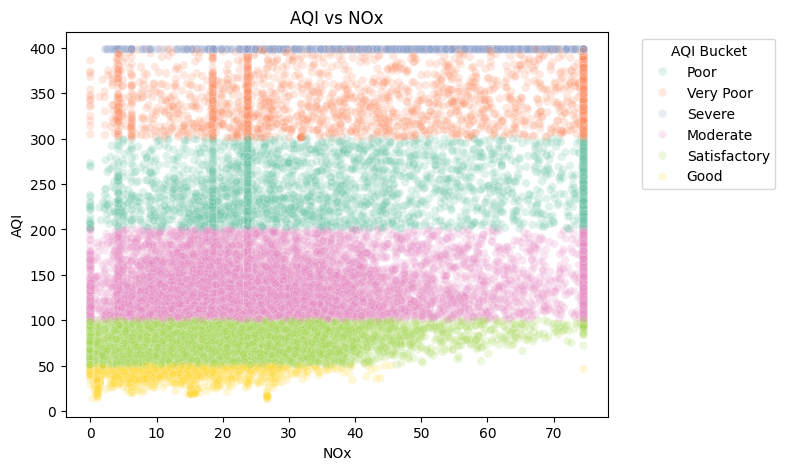

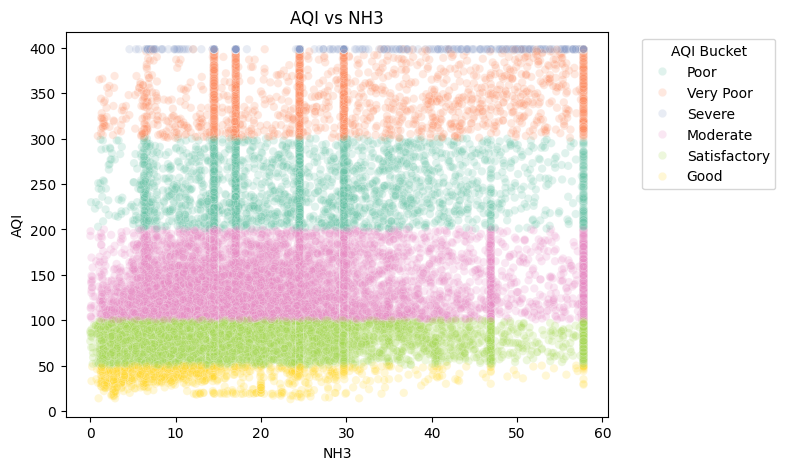

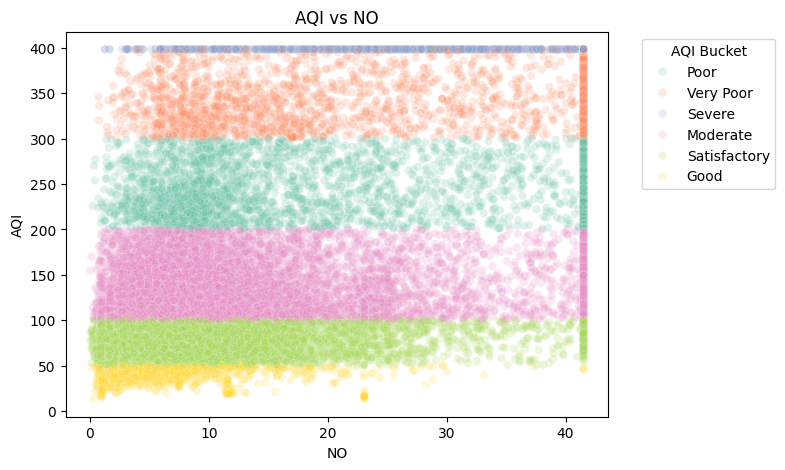

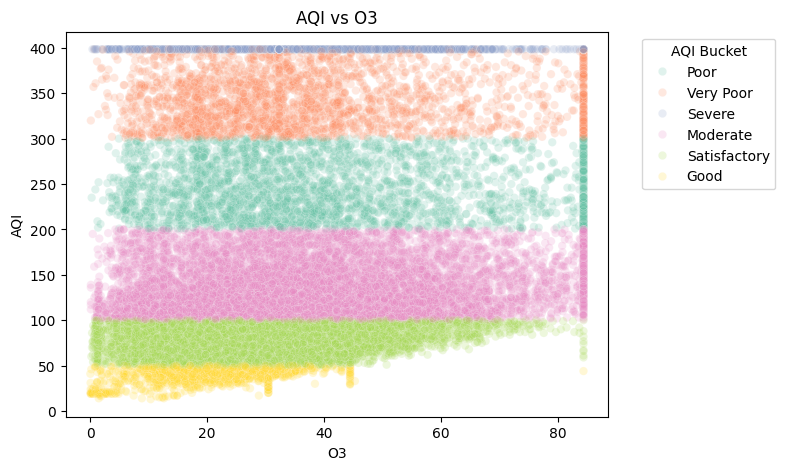

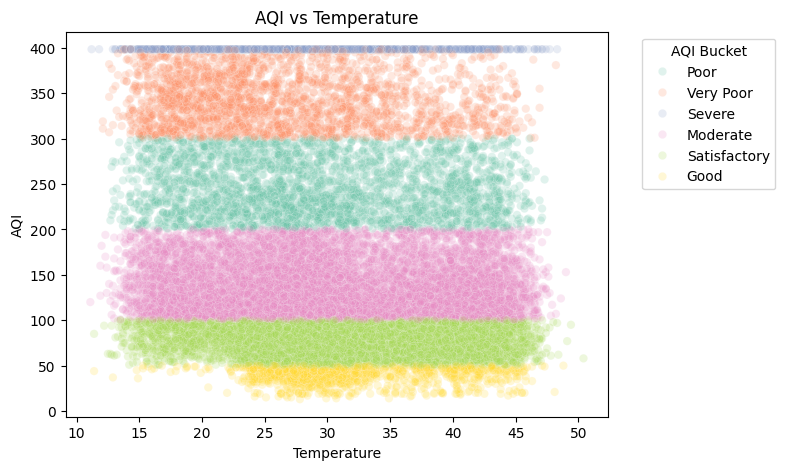

In [50]:
#AQI VS ALL POLLUTANTS
import seaborn as sns
import matplotlib.pyplot as plt

pollutants = ['PM2.5','PM10','NO2','SO2','CO','NOx','NH3','NO','O3','Temperature']

for col in pollutants:
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x=df[col], 
        y=df['AQI'], 
        hue=df['AQI_Bucket'],   # color by AQI category
        alpha=0.2,              # transparency to reduce clutter
        palette="Set2"
    )
    plt.title(f"AQI vs {col}")
    plt.xlabel(col)
    plt.ylabel("AQI")
    plt.legend(title="AQI Bucket", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


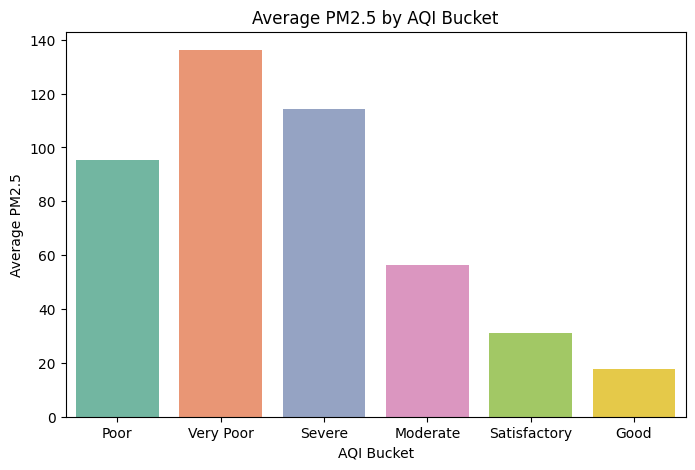

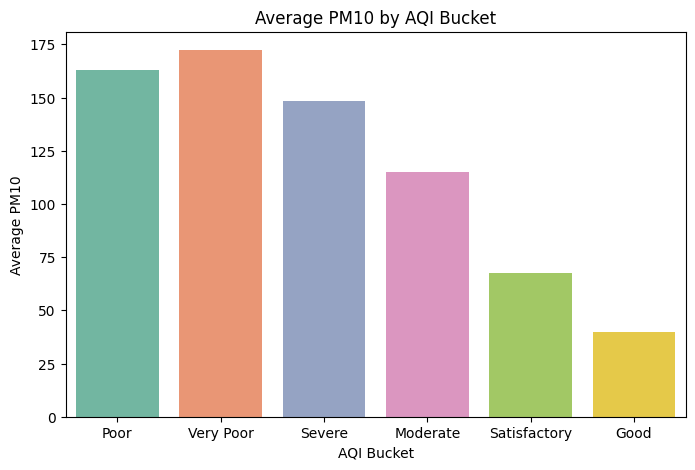

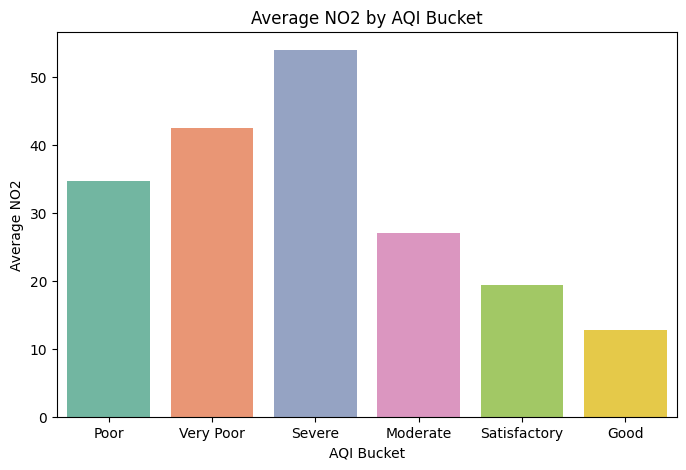

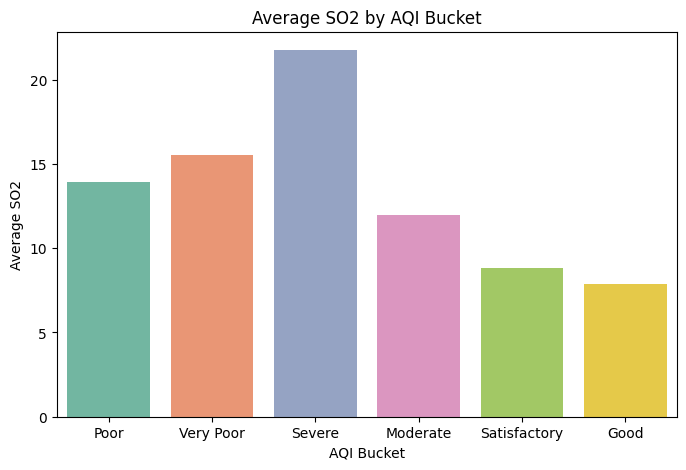

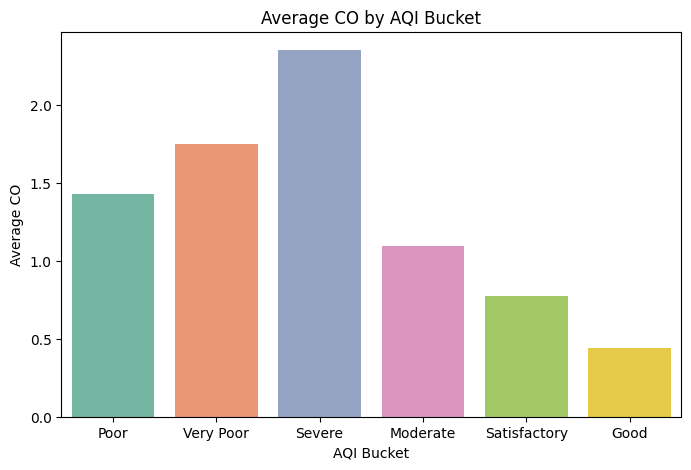

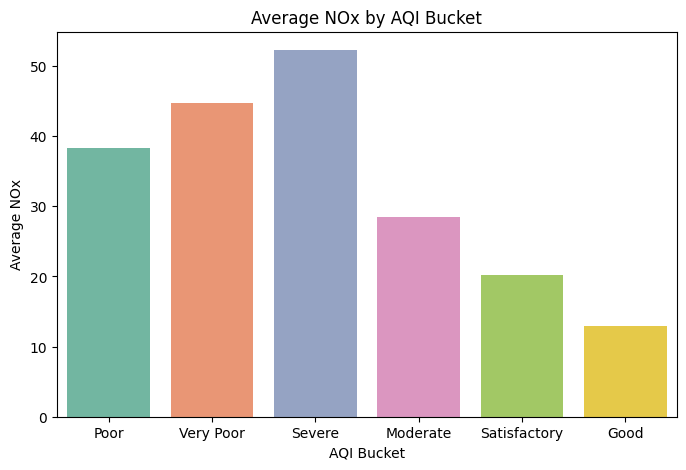

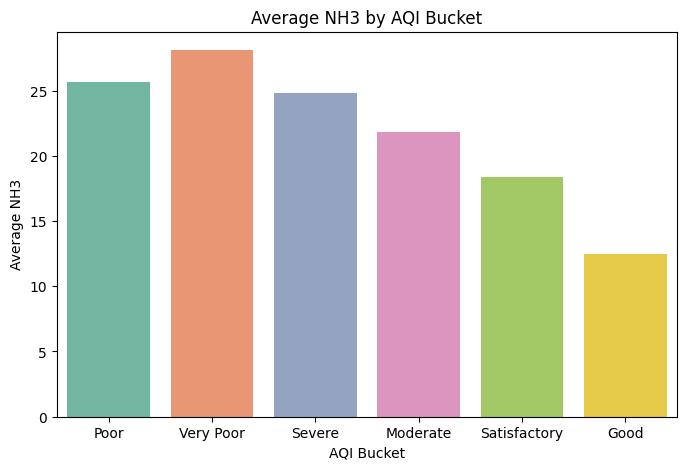

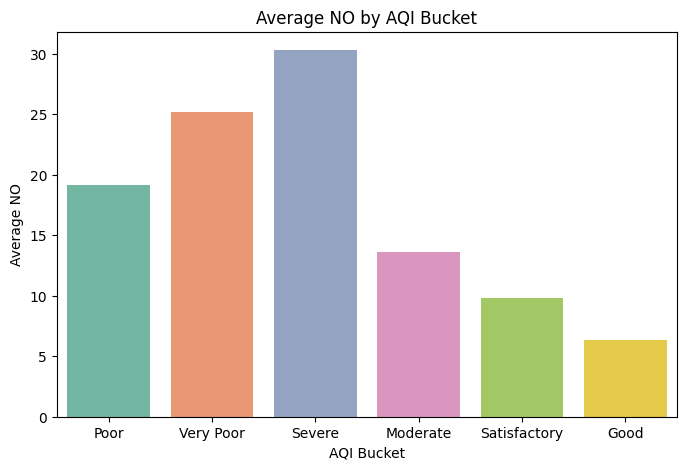

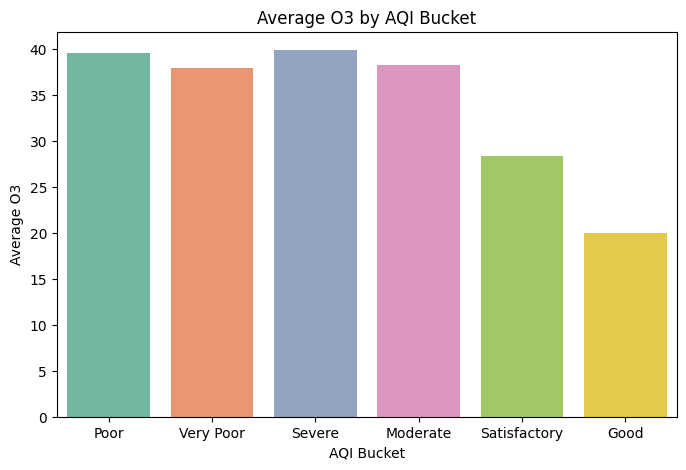

In [51]:

#AQI bucket VS AVERAGE POLLUTANT
import seaborn as sns
import matplotlib.pyplot as plt

pollutants = ['PM2.5','PM10','NO2','SO2','CO','NOx','NH3','NO','O3']

for col in pollutants:
    plt.figure(figsize=(8,5))
    sns.barplot(x='AQI_Bucket', y=col, data=df, palette="Set2", ci=None)
    plt.title(f"Average {col} by AQI Bucket")
    plt.xlabel("AQI Bucket")
    plt.ylabel(f"Average {col}")
    plt.show()


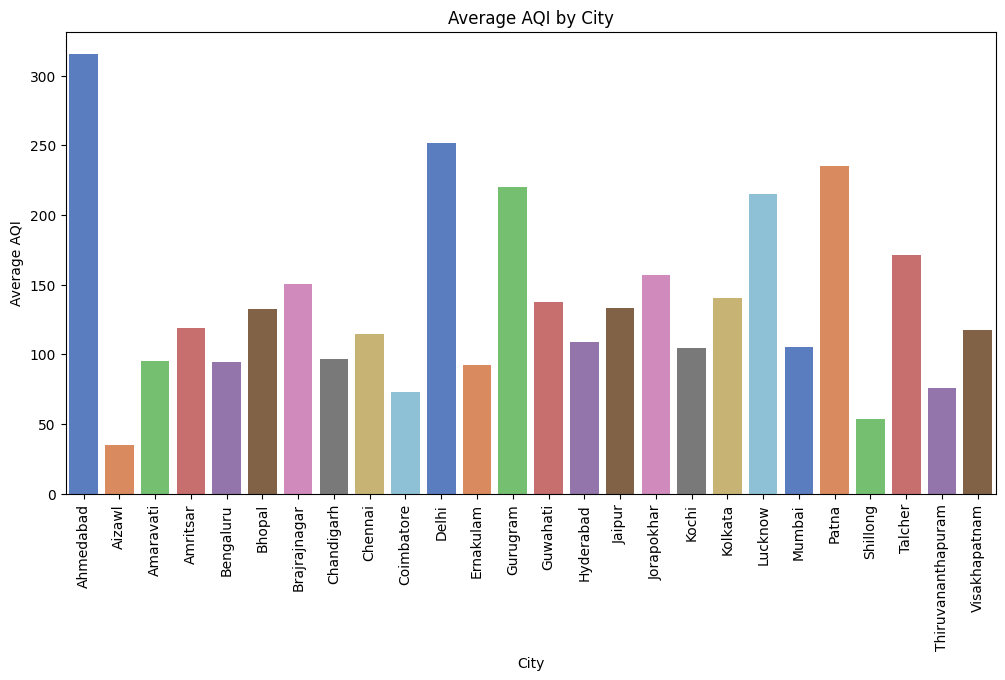

In [52]:
#AQI VS CITY
plt.figure(figsize=(12,6))
sns.barplot(x='City', y='AQI', data=df, palette="muted", ci=None)
plt.xticks(rotation=90)
plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.show()


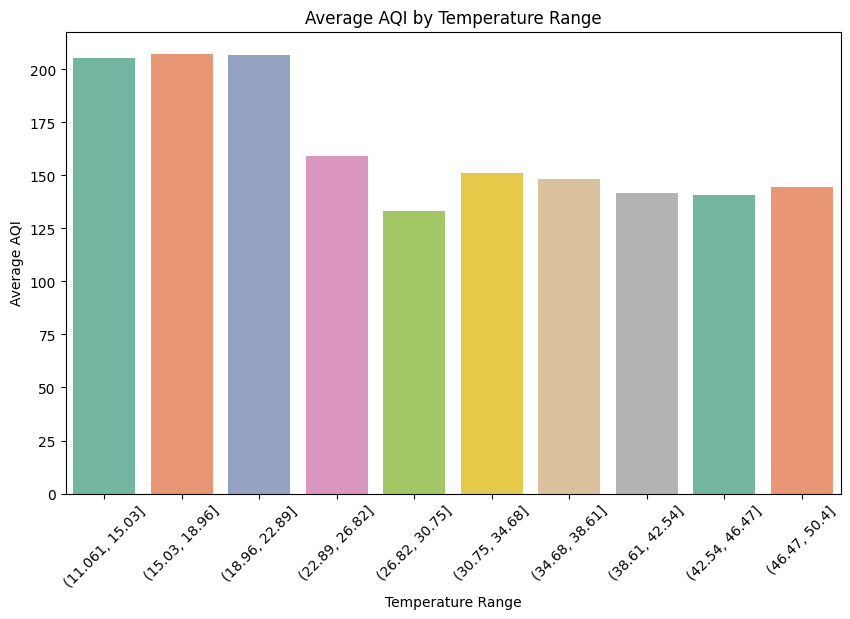

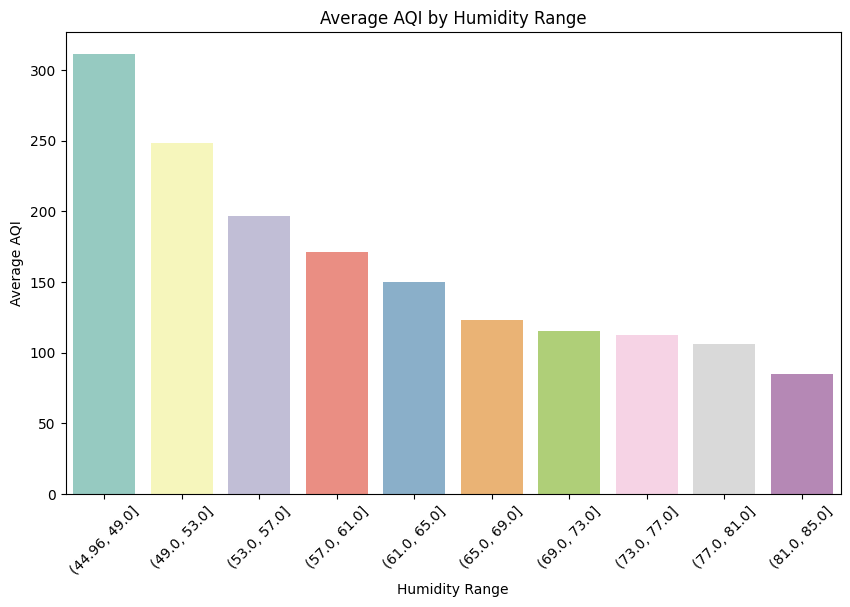

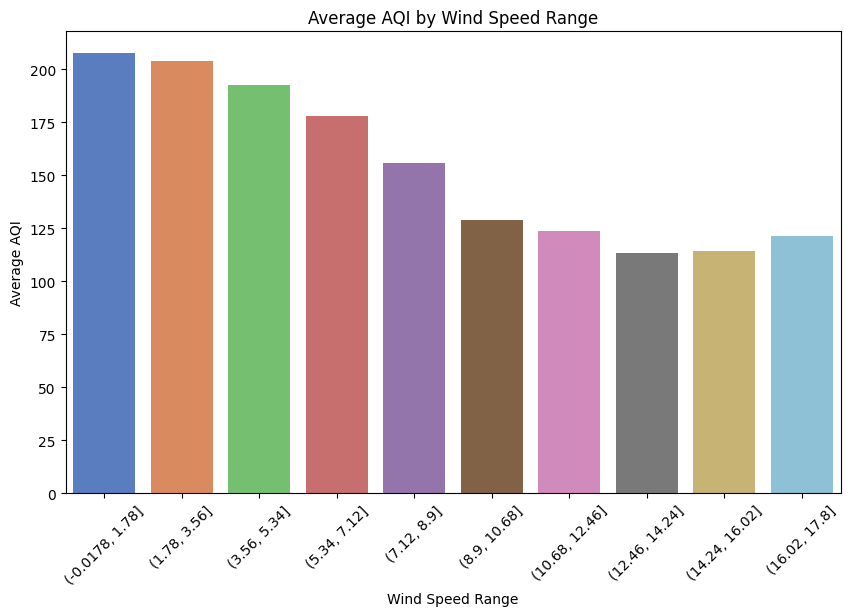

In [53]:
#AQI VS WEATHER
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create bins for continuous variables
df['Temp_bin'] = pd.cut(df['Temperature'], bins=10)   # 10 bins for Temperature
df['Humid_bin'] = pd.cut(df['Humidity'], bins=10)     # 10 bins for Humidity
df['Wind_bin'] = pd.cut(df['Wind_Speed'], bins=10)    # 10 bins for Wind Speed

# Temperature vs AQI
plt.figure(figsize=(10,6))
sns.barplot(x='Temp_bin', y='AQI', data=df, palette="Set2", ci=None)
plt.xticks(rotation=45)
plt.title("Average AQI by Temperature Range")
plt.xlabel("Temperature Range")
plt.ylabel("Average AQI")
plt.show()

# Humidity vs AQI
plt.figure(figsize=(10,6))
sns.barplot(x='Humid_bin', y='AQI', data=df, palette="Set3", ci=None)
plt.xticks(rotation=45)
plt.title("Average AQI by Humidity Range")
plt.xlabel("Humidity Range")
plt.ylabel("Average AQI")
plt.show()

# Wind Speed vs AQI
plt.figure(figsize=(10,6))
sns.barplot(x='Wind_bin', y='AQI', data=df, palette="muted", ci=None)
plt.xticks(rotation=45)
plt.title("Average AQI by Wind Speed Range")
plt.xlabel("Wind Speed Range")
plt.ylabel("Average AQI")
plt.show()


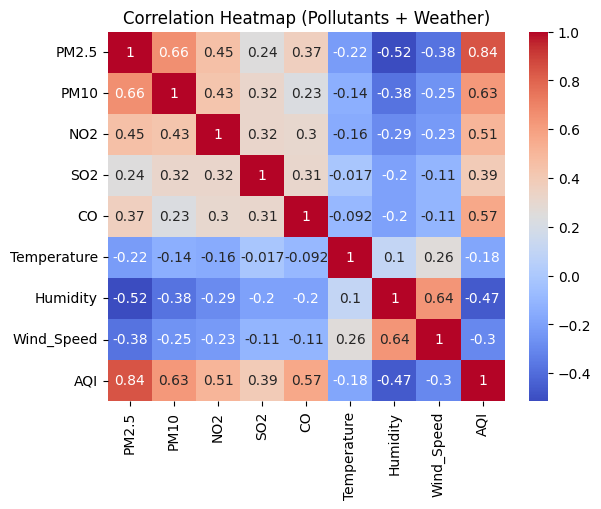

In [54]:
#MULTI VARIATE
features = ['PM2.5','PM10','NO2','SO2','CO','Temperature','Humidity','Wind_Speed']

sns.heatmap(df[features + ['AQI']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Pollutants + Weather)")
plt.show()

In [55]:
for col in ['PM2.5','PM10','NO2','SO2','CO','O3','Temperature','Humidity','Wind_Speed']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

PM2.5: 0 outliers
PM10: 0 outliers
NO2: 0 outliers
SO2: 0 outliers
CO: 0 outliers
O3: 0 outliers
Temperature: 0 outliers
Humidity: 0 outliers
Wind_Speed: 0 outliers


In [56]:
# Save final dataset
df_final.to_csv('../data/preprocessed/city_day_final_for_ml.csv', index=False)

print("✓ Dataset saved!")
print(f"Shape: {df_final.shape}")
print(f"Columns: {list(df_final.columns)}")

✓ Dataset saved!
Shape: (24850, 16)
Columns: ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI', 'AQI_Bucket', 'Month', 'Temperature', 'Humidity', 'Wind_Speed']
